# COMP9418 - Assignment 1 - Bayesian classifiers

- Student name 1 - zID1
- Student name 2 - zID2

## Instructions

This notebook is **self-contained**: all instructions, background, tasks, and marking information are included here. There is no separate assignment PDF.

**Submission deadline:** Sunday, 5th July 2026, at 18:00:00 (Sydney time).

**Late Submission Policy:** The penalty is $5\%$ per late day for a maximum of 5 days (the UNSW standard late penalty). For example, an on-time mark of $70/100$ submitted three days late receives a $70/100*15\%$ reduction. After five days, the reduction is $100\%$.

**Form of Submission:** This is an **individual** or group of **two students** assignment. Write the name(s) and zID(s) above. **If submitted in a group, only one member should submit the assignment. Also, create a group on WebCMS by clicking Groups and Create, and include both group members.

You can reuse any source code developed in the tutorials.

**How this assignment is marked.** Each coding task is assessed by **hidden test cases** (the visible self-checks in this notebook are only examples, they use different inputs from the hidden tests). The marks available for each task are shown in its heading. The report (Task 14) is marked against the rubric given in that task.

**Use the predefined data splits.** To make results reproducible and comparable, three fixed datasets are provided: `child_train.csv`, `child_calibration.csv`, and `child_test.csv`. Unless a task says otherwise, **learn everything (outcome space, parameters, structure) on the training set, and evaluate on the test set**; the calibration set is used only in Task 13. Do not re-split the data yourself.

## Technical prerequisites

These are the libraries you are allowed to use. **No other libraries will be accepted.** Make sure you are using Python 3.

For the calibration task (Task 13) you may use `sklearn.linear_model.LogisticRegression` to fit the Platt parameters. You may **not** use any ready-made probability-calibration utility (e.g. `sklearn.calibration.CalibratedClassifierCV`, `sklearn.isotonic`): the recalibration and ECE logic must be your own.

In [31]:
# Allowed libraries
import numpy as np
import pandas as pd
import scipy as sp
import heapq as pq
import matplotlib as mp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
from itertools import product, combinations
from graphviz import Digraph
from tabulate import tabulate
import copy
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression

def _test(statement):
    print("Passed test case" if statement else "Failed test case !!!")

We reuse the Python files developed in the tutorials: `DiscreteFactors.py`, `Graph.py`, and the variable-elimination version of the Bayes net library, `BayesNet_VE.py`. The cell below downloads them. (`BayesNet_VE` provides the inference primitives you may reuse: `learnParameters`, `joint`, `VE`, `width`, `interactionGraph`, `minDegree`, and the VE-based `query`.)

In [32]:
import urllib.request

base_url = "https://raw.githubusercontent.com/UNSW-COMP9418/libraries/main/"
files = ["DiscreteFactors.py", "Graph.py", "BayesNet_VE.py"]

for file in files:
    url = base_url + file
    print(url)
    print(f"Downloading {file}...")
    urllib.request.urlretrieve(url, file)

https://raw.githubusercontent.com/UNSW-COMP9418/libraries/main/DiscreteFactors.py
https://raw.githubusercontent.com/UNSW-COMP9418/libraries/main/Graph.py
https://raw.githubusercontent.com/UNSW-COMP9418/libraries/main/BayesNet_VE.py


In [33]:
from DiscreteFactors import Factor
from Graph import Graph
from BayesNet_VE import BayesNet

## Background: diagnosing congenital heart disease in newborns

A small fraction of newborn babies suffer from **congenital heart disease**: a structural defect of the heart present at birth. Some of these conditions are life-threatening in the first days of life: a "blue baby" whose blood is poorly oxygenated may need urgent treatment or transfer to a specialist cardiac centre. The difficulty is that in the first hours, a clinician must reach a diagnosis based on a handful of **indirect, observable signs**: blood-oxygen measurements, a chest X-ray, an ECG report, and simple clinical observations, without yet knowing the underlying cause. Getting this right quickly matters: an accurate, well-calibrated automated aid could help triage babies and prioritise the most urgent cases.

We model this problem using the **CHILD** Bayesian network (Spiegelhalter & Cowell), a real-world clinical decision-support model with **20 discrete variables**. The central class variable is **`Disease`**, with six possible diagnoses:

| `Disease` value | Meaning |
|---|---|
| `TGA` | Transposition of the great arteries |
| `Fallot` | Tetralogy of Fallot |
| `PAIVS` | Pulmonary atresia with intact ventricular septum |
| `TAPVD` | Total anomalous pulmonary venous drainage |
| `PFC` | Persistent fetal circulation |
| `Lung` | Lung disease (non-cardiac) |

The network has a clear **three-layer causal structure**: the disease at the top, a layer of intermediate physiological variables in the middle (e.g. `CardiacMixing`, `LungFlow`, `HypoxiaInO2`), and a bottom layer of **observable** measurements and reports. In practice, only the bottom layer is measured, while the physiological middle layer is hidden, which is exactly the *missing-evidence* setting of Task 6. The observable variables are:

| Observable variable | States | Meaning |
|---|---|---|
| `Age` | `0-3_days`, `4-10_days`, `11-30_days` | Age of the baby when assessed |
| `LowerBodyO2` | `<5`, `5-12`, `12+` | Oxygen partial pressure pO₂ (kPa) measured in the lower body (post-ductal) |
| `RUQO2` | `<5`, `5-12`, `12+` | Oxygen partial pressure pO₂ (kPa) measured in the right arm (pre-ductal) |
| `CO2Report` | `<7.5`, `>=7.5` | Reported blood CO₂ level (kPa) |
| `XrayReport` | `Normal`, `Oligaemic`, `Plethoric`, `Grd_Glass`, `Asy/Patchy` | Chest X-ray finding (lung vascularity / appearance) |
| `GruntingReport` | `yes`, `no` | Whether expiratory grunting (respiratory distress) was reported |
| `LVHreport` | `yes`, `no` | Whether the ECG report indicates left ventricular hypertrophy |

## Task 0 - Initialise graph

The dictionary below is the **true** CHILD DAG, given as an adjacency list mapping each node to the list of its **children**.

In [34]:
G = Graph({
    'BirthAsphyxia': ['Disease'],
    'Disease': ['Age', 'LVH', 'DuctFlow', 'CardiacMixing', 'LungParench', 'LungFlow', 'Sick'],
    'LVH': ['LVHreport'],
    'DuctFlow': ['HypDistrib'],
    'CardiacMixing': ['HypDistrib', 'HypoxiaInO2'],
    'LungParench': ['HypoxiaInO2', 'CO2', 'ChestXray', 'Grunting'],
    'LungFlow': ['ChestXray'],
    'Sick': ['Grunting', 'Age'],
    'LVHreport': [],
    'HypDistrib': ['LowerBodyO2'],
    'HypoxiaInO2': ['LowerBodyO2', 'RUQO2'],
    'CO2': ['CO2Report'],
    'ChestXray': ['XrayReport'],
    'Grunting': ['GruntingReport'],
    'Age': [],
    'LowerBodyO2': [],
    'RUQO2': [],
    'CO2Report': [],
    'XrayReport': [],
    'GruntingReport': [],
})

# The bottom-layer variables a clinician actually observes (used in Task 6).
observable_vars = ['LVHreport', 'LowerBodyO2', 'RUQO2', 'CO2Report',
                   'XrayReport', 'GruntingReport', 'Age']

This is what the network looks like:

![The CHILD network](https://www.bnlearn.com/bnrepository/child/child.svg)

### Load the predefined data splits

`train` (12,000) is used for learning; `test` (4,000) for evaluation; `calibration` (4,000) only in Task 13. All splits are complete (no missing values) and stratified by `Disease`.

In [35]:
train       = pd.read_csv('child_train.csv')
calibration = pd.read_csv('child_calibration.csv')
test        = pd.read_csv('child_test.csv')
print('train / calibration / test sizes:', len(train), len(calibration), len(test))
train.head()

train / calibration / test sizes: 12000 4000 4000


,BirthAsphyxia,Disease,LVH,DuctFlow,CardiacMixing,LungParench,LungFlow,Sick,LVHreport,HypDistrib,HypoxiaInO2,CO2,ChestXray,Grunting,Age,LowerBodyO2,RUQO2,CO2Report,XrayReport,GruntingReport
0,no,Lung,no,Rt_to_Lt,Absent,Abnormal,Normal,yes,no,Unequal,Mild,Normal,Normal,yes,0-3_days,5-12,12+,<7.5,Normal,yes
1,no,Fallot,no,Lt_to_Rt,Complete,Abnormal,Low,no,no,Equal,Severe,High,Oligaemic,no,11-30_days,<5,5-12,>=7.5,Oligaemic,no
2,no,Fallot,yes,Lt_to_Rt,Complete,Normal,Low,no,yes,Equal,Moderate,High,Oligaemic,no,11-30_days,5-12,5-12,>=7.5,Oligaemic,no
3,no,PAIVS,yes,Lt_to_Rt,Complete,Normal,Low,no,yes,Equal,Moderate,High,Oligaemic,no,0-3_days,5-12,5-12,>=7.5,Asy/Patchy,no
4,no,TAPVD,yes,Lt_to_Rt,Complete,Congested,Normal,no,yes,Equal,Moderate,Normal,Asy/Patch,no,0-3_days,5-12,5-12,<7.5,Asy/Patchy,no


## [10 Marks] Task 1 - Efficient d-separation test

Implement the efficient (graph-pruning) version of the d-separation algorithm in `BN.d_separation(X, Z, Y)`, which returns `True` if **X** is d-separated from **Y** given **Z**, and `False` otherwise. The algorithm prunes leaf nodes not in $X\cup Y\cup Z$, removes edges outgoing from $Z$, and then tests whether $X$ and $Y$ are disconnected in the resulting undirected graph. See page 66 of the textbook (Darwiche).

**Marking (10 marks):** assessed by hidden test cases covering a range of $(X, Z, Y)$ triples.

In [36]:
# Develop your code for BN.d_separation(X, Z, Y) in this cell

class BayesNet(BayesNet):

    def d_separation(self, X, Z, Y):
        '''
        Arguments:
            X, Z and Y:  Python set objects with node identifiers.
        Returns:
            True if X is d-separated from Y given Z or False otherwise.
        '''
        G = self.graph.copy()

        protected = X | Y | Z


        # Repeatedly prune irrelevant leaf nodes
        while True:
            leaf_nodes = [
                node for node in G
                if node not in protected
                and len(G.children(node)) == 0
            ]

            if not leaf_nodes:
                break

            for node in leaf_nodes:
                G.remove_node(node)

        # Remove outgoing edges from Z
        for node in Z:
            G.remove_outgoing_from(node)

        # Convert to an undirected graph
        G = G.convert_to_undirected()

        # Test connectivity
        for x in X:
            colours = G.dfs(x)

            if any(colours[y] == 'black' for y in Y):
                return False

        return True

In [37]:
# Self-check (examples only, the hidden marking tests use different cases)

BN = BayesNet(G)

_test(BN.d_separation({'Age'}, {'Disease'}, {'CO2'}))                 # True
_test(BN.d_separation({'LVHreport'}, {'LVH'}, {'Disease'}))           # True
_test(BN.d_separation({'HypDistrib'}, {'Disease'}, {'CO2'}))          # True
_test(not BN.d_separation({'GruntingReport'}, set(), {'XrayReport'})) # connected -> not d-sep
_test(not BN.d_separation({'HypDistrib'}, set(), {'CO2'}))            # connected -> not d-sep

Passed test case
Passed test case
Passed test case
Passed test case
Passed test case


## [5 Marks] Task 2 - Markov blanket

Implement `BN.Markov_blanket(X)`, returning a Python `set` with the Markov blanket of `X`: its parents, its children, and its spouses (the other parents of its children).

**Marking (5 marks):** assessed by hidden test cases over several nodes.

In [38]:
# Develop your code for BN.Markov_blanket(X) in this cell

class BayesNet(BayesNet):

    def Markov_blanket(self, X):
        '''
        Arguments:
            X:  A node identifier (string).
        Returns:
            A Python set with the Markov blanket of X.
        '''
        blanket = set()

        # Add all parents of X
        parents = self.graph.transpose().children(X)
        blanket.update(parents)

        # Add all children of X
        blanket.update(self.graph.children(X))

        # Add all spouses of X (parents of children of X)
        for child in self.graph.children(X):
            blanket.update(self.graph.transpose().children(child))

        # Remove X from the blanket if it was added
        blanket.discard(X)

        return blanket

In [39]:
# Self-check (examples only, the hidden marking tests use different cases)

BN = BayesNet(G)

_test(BN.Markov_blanket('CO2') == {'CO2Report', 'LungParench'})
_test(BN.Markov_blanket('Disease') == {'Age', 'DuctFlow', 'BirthAsphyxia', 'LungFlow', 'CardiacMixing', 'LVH', 'Sick', 'LungParench'})

Passed test case
Passed test case


## Putting Tasks 1 and 2 together

A Markov blanket $B$ of $X$ satisfies $X \perp \mathbf{X}\setminus(B\cup\{X\}) \mid B$. Use your d-separation test to verify, for every node $X$, that $X$ is d-separated from all non-blanket variables given its Markov blanket.

In [40]:
# Develop your code to test your d-separation and Markov blanket implementations using the definition above.

BN = BayesNet(G)
all_nodes = set(G.adj_list.keys())
for X in all_nodes:
    mb =  BN.Markov_blanket(X)                         # Markov blanket of X
    rest = all_nodes - (mb | {X})                     # X \ (mb u {X})
    assert BN.d_separation({X}, mb, rest), f"Failed d-separation test for node {X}"

## [5 Marks] Task 3 - Learning the outcome space from data

Implement `BN.learn_outcome_space(data)`, which learns the outcome space (a dictionary mapping each variable to a tuple of its possible outcomes) directly from the pandas dataframe `data`, and stores it in `self.outcomeSpace`.

**Marking (5 marks):** assessed by hidden test cases.

In [41]:
# Develop your code for BN.learn_outcome_space(data) in this cell

class BayesNet(BayesNet):

    def learn_outcome_space(self, data):
        '''
        Arguments:
            data:  A pandas dataframe.
        Returns:
            Sets self.outcomeSpace to a dictionary {var: tuple(outcomes)} learned from data.
        '''
        self.outcomeSpace = {
        column: tuple(data[column].unique())
        for column in data.columns
    }

In [42]:
# Self-check (examples only, the hidden marking tests use different cases)

BN = BayesNet(G); BN.learn_outcome_space(train)
_test(len(BN.outcomeSpace) == 20)
_test(set(BN.outcomeSpace['Disease']) == {'Fallot', 'Lung', 'PAIVS', 'PFC', 'TAPVD', 'TGA'})
_test(set(BN.outcomeSpace['LowerBodyO2']) == {'12+', '5-12', '<5'})

Passed test case
Passed test case
Passed test case


## [5 Marks] Task 4 - Estimate Bayesian network parameters from data

Implement `BN.learn_parameters(data, alpha)`, which estimates and stores the conditional probability table of each node. It must behave like the tutorial `learnParameters`, but apply **additive (Laplace) smoothing** with parameter `alpha`. Learn parameters on the **training set**.

**Marking (5 marks):** assessed by hidden test cases (correct probabilities, with and without smoothing).

In [43]:
## Develop your code for BN.learn_parameters(data, alpha) in this cell

class BayesNet(BayesNet):

    def learn_parameters(self, data, alpha):
        '''
        Arguments:
            data:   A pandas dataframe.
            alpha:  Additive smoothing parameter.
        Returns:
            Sets self.factors with the smoothed conditional probability tables.
        '''
        self.factors = {}

        reversed_graph = self.graph.transpose()

        for node in self.graph:
            parents = reversed_graph.children(node)
            outcomes = self.outcomeSpace[node]

            domain = list(parents) + [node]
            factor = Factor(domain, self.outcomeSpace)

            parent_outcome_spaces = [
                self.outcomeSpace[parent]
                for parent in parents
            ]

            for parent_values in product(*parent_outcome_spaces):

                parent_mask = np.ones(len(data), dtype=bool)

                for parent, value in zip(parents, parent_values):
                    parent_mask &= (
                        data[parent].to_numpy() == value
                    )

                parent_count = parent_mask.sum()

                k = len(outcomes)
                denominator = parent_count + alpha * k

                for outcome in outcomes:
                    joint_count = (
                        parent_mask
                        & (data[node].to_numpy() == outcome)
                    ).sum()

                    probability = (
                        joint_count + alpha
                    ) / denominator

                    factor[parent_values + (outcome,)] = probability

            self.factors[node] = factor
        

## [5 Marks] Task 5 - Bayesian network classification (complete data)

Implement `BN.predict_proba(class_var, evidence)` and `BN.predict(class_var, evidence)` for the case of **complete** evidence, i.e. `evidence` instantiates **all** variables except `class_var`.

This must be **efficient**: with complete evidence the computation involves only the factors that mention `class_var` (its family), after setting the evidence with `evidence2`. `predict_proba` returns a normalised `DiscreteFactor` over `class_var`; `predict` returns its MPE value.

**Marking (5 marks):** assessed by hidden test cases checking the returned distribution and the predicted label.

In [44]:
## Develop your code for BN.predict_proba(class_var, evidence) and BN.predict(class_var, evidence) in this cell

class BayesNet(BayesNet):

    def predict_proba(self, class_var, evidence):
        '''
        Arguments:
            class_var:   Variable identifier to be classified.
            evidence:    Python dictionary instantiating all variables but class_var.
        Returns:
            A factor over class_var with the probability of each value given evidence.
        '''
        f = Factor(tuple(), {})  # trivial factor
        
        for factor in self.factors.values():
            if class_var in factor.domain:
                reduced = factor.evidence2(**evidence)
                f = f * reduced

        return f.normalize()

    def predict(self, class_var, evidence):
        '''
        Returns the MPE value (class label) of class_var given evidence.
        '''
        f = self.predict_proba(class_var, evidence)
        idx = np.argmax(f.table)
        return f.outcomeSpace[class_var][idx]

In [45]:
# Self-check (examples only, the hidden marking tests use different cases)

BN = BayesNet(G); BN.learn_outcome_space(train); BN.learn_parameters(train, alpha=1)
row = test.iloc[50]
evi = {c: row[c] for c in test.columns if c != 'Disease'}
_test(BN.predict('Disease', evi) == 'PAIVS')
_test(np.isclose(float(BN.predict_proba('Disease', evi)['PAIVS']), 0.966341, atol=1e-3))

Passed test case
Passed test case


## [10 Marks] Task 6 - Bayesian network classification with missing evidence

In practice we rarely observe every variable. Implement classification when only a **subset** of variables is observed, so the unobserved variables must be **summed out** by variable elimination.

Implement `BN.predict_proba_missing(class_var, evidence)` and a corresponding `predict_missing`, where `evidence` instantiates **only some** of the variables. Use the VE primitives (`query`, or `VE` together with `minDegree`) over the relevant sub-network. The driving scenario for CHILD: classify `Disease` from only the seven `observable_vars` (bottom layer), with the intermediate physiological variables unobserved.

In your report, explain why the complete-data shortcut of Task 5 no longer applies here.

**Marking (10 marks):** assessed by hidden test cases with varying subsets of observed variables.

In [46]:
## Develop your code for BN.predict_proba_missing(class_var, evidence) in this cell

class BayesNet(BayesNet):

    def predict_proba_missing(self, class_var, evidence):
        '''
        Arguments:
            class_var:   Variable identifier to be classified.
            evidence:    Python dictionary instantiating SOME variables (others are unobserved).
        Returns:
            A normalised factor over class_var: P(class_var | evidence).
        '''
        return self.query([class_var], **evidence)

    def predict_missing(self, class_var, evidence):
        '''
        Returns the MPE value of class_var given partial evidence.
        '''
        f = self.predict_proba_missing(class_var, evidence)
        idx = np.argmax(f.table)
        return f.outcomeSpace[class_var][idx]

In [47]:
# Self-check (examples only, the hidden marking tests use different cases)

BN = BayesNet(G)
BN.learn_outcome_space(train)
BN.learn_parameters(train, alpha=1)
row = test.iloc[50]
evidence = {v: row[v] for v in observable_vars}
f = BN.predict_proba_missing('Disease', evidence)
print(f)
print('MPE:', BN.predict_missing('Disease', evidence), '  true:', row['Disease'])

_test(BN.predict_missing('Disease', evidence) == 'PAIVS')
_test(np.isclose(float(f.table.max()), 0.663858, atol=1e-3))
_test(np.isclose(float(f.table.sum()), 1.0, atol=1e-6))

╒═══════════╤═══════════╕
│ Disease   │        Pr │
╞═══════════╪═══════════╡
│ Lung      │ 0.0352158 │
├───────────┼───────────┤
│ Fallot    │ 0.0721421 │
├───────────┼───────────┤
│ PAIVS     │ 0.663858  │
├───────────┼───────────┤
│ TAPVD     │ 0.0139461 │
├───────────┼───────────┤
│ TGA       │ 0.145885  │
├───────────┼───────────┤
│ PFC       │ 0.0689532 │
╘═══════════╧═══════════╛

MPE: PAIVS   true: Fallot
Passed test case
Passed test case
Passed test case


## [5 Marks] Task 7 - Naïve Bayes classifier structure

Create a `NaiveBayes` class that inherits from `BayesNet`, and implement `NB.learn_structure(data, class_var)`, which builds the Naïve Bayes graph (the class variable as the single parent of every attribute) and stores it in `self.graph`.

**Marking (5 marks):** assessed by hidden test cases on the learned structure.

In [48]:
## Develop your code for NB.learn_structure(data, class_var) in this cell

class NaiveBayes(BayesNet):

    def learn_structure(self, data, class_var):
        '''
        Arguments:
            data:        A pandas dataframe.
            class_var:   The class variable identifier.
        Returns:
            Sets self.graph with the Naïve Bayes structure for the attributes in data.
        '''
        self.graph = Graph()

        for var in data.columns:
            self.graph.add_node(var)

        for var in data.columns:
            if var != class_var:
                self.graph.add_edge(class_var, var)

In [49]:
# Self-check (examples only, the hidden marking tests use different cases)

nb = NaiveBayes(); 
nb.learn_structure(train, 'Disease')
_test(len(nb.graph.adj_list['Disease']) == 19)               # class is parent of all 19 attributes
_test(set(nb.graph.transpose().adj_list['Grunting']) == {'Disease'})

Passed test case
Passed test case


## [5 Marks] Task 8 - Naïve Bayes classification

Implement the Naïve Bayes classifier using **log probabilities** (the standard numerically-stable approach for classifiers with many attributes).

Implement `NB.predict_log_proba(class_var, evidence)` and `NB.predict(class_var, evidence)`. Your implementation must handle **both** complete evidence **and missing evidence**: when a variable is not present in `evidence`, simply omit its term from the log-sum (a key advantage of Naïve Bayes over the full network).

**Marking (5 marks):** assessed by hidden test cases with complete and partial evidence.

In [50]:
## Develop your code for NB.predict_log_proba and NB.predict in this cell

class NaiveBayes(NaiveBayes):

    def predict_log_proba(self, class_var, evidence):
        '''
        Arguments:
            class_var:   Variable identifier to be classified.
            evidence:    Python dictionary instantiating all OR some variables (others omitted).
        Returns:
            A factor over class_var with log-probabilities given the available evidence.
        '''
        labels = self.outcomeSpace[class_var]

        f = Factor((class_var,), self.outcomeSpace)

        for label in labels:
            log_prob = np.log(self.factors[class_var][label])  # log P(class_var=label)

            for var, value in evidence.items():
                if var == class_var:
                    continue  # Skip the class variable itself

                if var in self.factors:
                    factor = self.factors[var]
                    log_prob += np.log(
                        self.factors[var][label, value]
                    )  # log P(var=value | class_var=label) 

            f[label] = log_prob
        return f

    def predict(self, class_var, evidence):
        '''
        Returns the MPE value of class_var given evidence (complete or partial).
        '''
        f = self.predict_log_proba(class_var, evidence)
        idx = np.argmax(f.table)
        return f.outcomeSpace[class_var][idx]

In [51]:
# Self-check (examples only, the hidden marking tests use different cases)

nb = NaiveBayes()
nb.learn_structure(train, 'Disease')
nb.learn_outcome_space(train)
nb.learn_parameters(train, 1)
row = test.iloc[50]
evi = {c: row[c] for c in test.columns if c != 'Disease'}
_test(nb.predict('Disease', evi) == 'PAIVS')

Passed test case


## [10 Marks] Task 9 - Tree-augmented Naïve Bayes (TAN) structure

Implement `TAN.learn_structure(data, class_var)`. TAN allows each attribute to have, in addition to the class, **at most one other attribute** as a parent. The tree over attributes is the maximum spanning tree whose edge weights are the **conditional mutual information**

$$ w(A_i, A_j) = I(A_i ; A_j \mid C) $$

between attribute pairs given the class $C$ (see **Lecture 6, slide 24** for the full algorithm; conditional mutual information generalises the mutual information of Lecture 3). Build the complete weighted graph, take a maximum spanning tree, root it at any attribute and direct edges outward, then add the class as a parent of every attribute. Store the result in `self.graph`.

*(In your report, you may briefly compare the learned tree backbone against the true CHILD DAG.)*

**Marking (10 marks):** assessed by hidden test cases on the conditional mutual information values and the learned structure.

In [52]:
## Develop your code for TAN.learn_structure(data, class_var) in this cell

class TANet(BayesNet):

    def conditional_mutual_information(self, data, A_i, A_j, class_var):
        '''
        Returns I(A_i ; A_j | class_var) estimated from data.
        '''
        total = len(data)
        cmi = 0.0

        for ai in data[A_i].unique():
            for aj in data[A_j].unique():
                for c in data[class_var].unique():

                    p_ai_aj_c = (
                        ((data[A_i] == ai) &
                         (data[A_j] == aj) &
                         (data[class_var] == c)).sum()
                        / total
                    )

                    if p_ai_aj_c == 0:
                        continue

                    p_c = (data[class_var] == c).sum() / total

                    p_ai_c = (
                        ((data[A_i] == ai) &
                         (data[class_var] == c)).sum()
                        / total
                    )

                    p_aj_c = (
                        ((data[A_j] == aj) &
                         (data[class_var] == c)).sum()
                        / total
                    )

                    cmi += p_ai_aj_c * np.log(
                        (p_ai_aj_c * p_c) / (p_ai_c * p_aj_c)
                    )

        return cmi

    def learn_structure(self, data, class_var):
        '''
        Arguments:
            data:        A pandas dataframe.
            class_var:   The class variable identifier.
        Returns:
            Sets self.graph with the TAN structure.
        '''
        attributes = [v for v in data.columns if v != class_var]

        weighted_graph = Graph()

        for attr in attributes:
            weighted_graph.add_node(attr)

        for i in range(len(attributes)):
            for j in range(i + 1, len(attributes)):
                A_i = attributes[i]
                A_j = attributes[j]

                cmi = self.conditional_mutual_information(
                    data, A_i, A_j, class_var
                )

                # negative because Graph.prim gives minimum spanning tree
                weighted_graph.add_edge(A_i, A_j, weight=-cmi, directed=False)

        root = attributes[0]
        tree = weighted_graph.prim(root)

        self.graph = Graph()

        for var in data.columns:
            self.graph.add_node(var)

        # add directed tree edges between attributes
        for parent in tree:
            for child in tree.children(parent):
                self.graph.add_edge(parent, child)

        # add class -> every attribute
        for attr in attributes:
            self.graph.add_edge(class_var, attr)

In [53]:
# Self-check (examples only, the hidden marking tests use different cases)

tan = TANet(); 
tan.learn_structure(train, 'Disease')
_test(np.isclose(tan.conditional_mutual_information(train, 'LowerBodyO2', 'RUQO2', 'Disease'), 0.008634, atol=1e-4))

attrs = [c for c in train.columns if c != 'Disease']
gT = tan.graph.transpose()
# the attribute tree must have exactly |attrs| - 1 edges (each attribute has <= 1 attribute-parent)
_test(sum(1 for a in attrs for p in gT.adj_list[a] if p != 'Disease') == len(attrs) - 1)

Passed test case
Passed test case


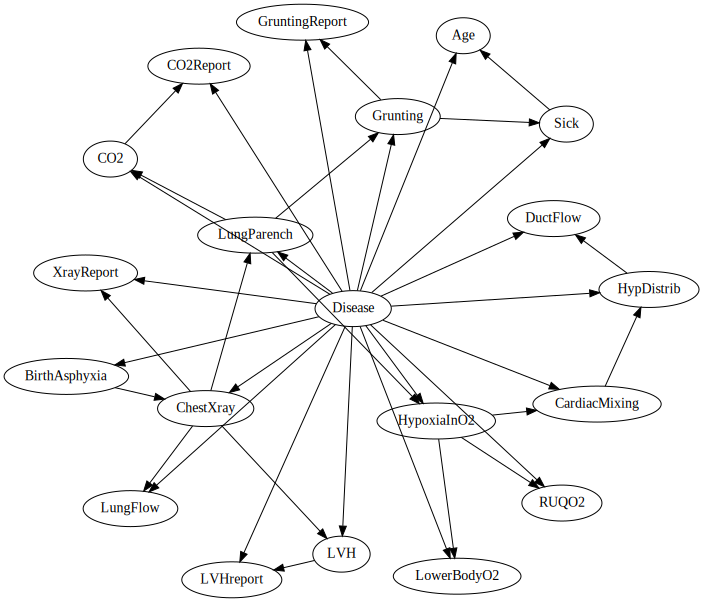

In [59]:
tan.graph.show()

## [5 Marks] Task 10 - Accuracy and per-class (balanced) accuracy

Implement two evaluation functions and evaluate models on the **test set**.

`assess(model, data, class_var)` returns the overall **accuracy**: the fraction of instances whose predicted label equals the true label.

`balanced_accuracy(model, data, class_var)` returns the **balanced accuracy**. *Recall* for a class $c$ is the fraction of the instances that truly belong to $c$ that the model labels as $c$ (i.e. per-class accuracy). Balanced accuracy is the **unweighted mean of the per-class recalls**:

$$ \text{balanced accuracy} = \frac{1}{|C|}\sum_{c\in C} \text{recall}(c). $$

The `Disease` classes are imbalanced. The three commonest diagnoses account for most of the data, while `PFC`, `TAPVD`, and `Lung` are rare. Plain accuracy is dominated by the frequent classes, so a model that does well only on the common diagnoses can still score highly while missing the rare ones. Clinically, rare conditions matter just as much, so balanced accuracy, which weights each disease equally regardless of frequency, provides a fairer picture of performance.

**Marking (5 marks):** assessed by hidden test cases on both functions.

In [54]:
## Develop your code for assess and balanced_accuracy in this cell

def assess(model, data, class_var):
    '''
    Returns the overall accuracy (in [0,1]) of model on data.
    '''
    ...
    return ...

def balanced_accuracy(model, data, class_var):
    '''
    Returns the mean per-class recall (balanced accuracy) of model on data.
    '''
    ...
    return ...

## [5 Marks] Task 11 - Assessment with cross-validation

Implement `cross_validation(model, data, class_var, k)`, returning the **mean** and **standard deviation** of the accuracy of `model` under $k$-fold cross-validation, run on the **training set**. Use the `assess` function from Task 10 on each fold.

For reproducibility, create the folds with **`KFold(n_splits=k, shuffle=True, random_state=42)`**.

**Marking (5 marks):** assessed by hidden test cases.

In [55]:
## Develop your code for cross_validation(model, data, class_var, k) in this cell

def cross_validation(model, data, class_var, k):
    '''
    Returns (mean_accuracy, std_accuracy) over k folds, using
    KFold(n_splits=k, shuffle=True, random_state=42).
    '''
    ...
    return ...

## [5 Marks] Task 12 - Reliability diagram and Expected Calibration Error (ECE)

A well-calibrated classifier's predicted probabilities match observed frequencies. We assess calibration on the **test set**, with respect to a chosen positive label `pos_label`.

**(a)** Implement `bin_pos_prob(model, data, class_var, pos_label, bins)`. It splits the instances into `bins` equal-width bins according to the predicted probability $P(\text{class\_var}=\text{pos\_label}\mid\text{evidence})$, and returns three arrays indexed by bin number $i$:

- `inst_num[i]` $= |B_i|$ — the number of instances in bin $i$;
- `pos_ratio[i]` $= \text{acc}(B_i)$ — the observed fraction of instances in bin $i$ that are actually `pos_label`;
- `mean_pos_prob[i]` $= \text{conf}(B_i)$ — the mean predicted positive probability over the instances in bin $i$.

**(b)** Implement `ece(model, data, class_var, pos_label, bins)`. With $n$ the total number of instances and $b$ the number of bins,

$$ \mathrm{ECE} = \sum_{i=1}^{b} \frac{|B_i|}{n}\,\bigl|\,\mathrm{acc}(B_i) - \mathrm{conf}(B_i)\,\bigr| , $$

**Marking (5 marks):** assessed by hidden test cases on `bin_pos_prob` and `ece`.

In [56]:
## Develop your code for bin_pos_prob(model, data, class_var, pos_label, bins) in this cell

def bin_pos_prob(model, data, class_var, pos_label, bins):
    '''
    Returns three arrays indexed by bin i:
        inst_num[i]      = |B_i|      number of instances in bin i
        pos_ratio[i]     = acc(B_i)   fraction of actual positives in bin i
        mean_pos_prob[i] = conf(B_i)  mean predicted positive probability in bin i
    '''
    ...
    return inst_num, pos_ratio, mean_pos_prob

### Reliability diagram (provided)

In [57]:
def reliability_plot(model, data, class_var, pos_label, bins=10):
    '''Plots the reliability diagram of the model on data (provided).'''
    inst_num, pos_ratio, mean_pos_prob = bin_pos_prob(model, data, class_var, pos_label, bins)

    fig = plt.figure(figsize=(6, 8))
    gs = GridSpec(2, 1, height_ratios=[1, .25])
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1:, 0])

    ax0.plot(mean_pos_prob, pos_ratio, "s-", label="Calibration Curve")
    ax0.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
    ax0.set_title('Reliability Diagram')
    ax0.set_xlabel('Mean Positive Probability  (conf)')
    ax0.set_ylabel('Fraction of Actual Positives  (acc)')
    ax0.legend()

    bin_edges = np.linspace(0.0, 1.0, bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax1.bar(bin_centers, inst_num, edgecolor='black', width=0.1)
    ax1.set_title('Histogram of Positive Counts')
    ax1.set_xlabel('Mean Positive Probability  (conf)')
    ax1.set_ylabel('Instance Count')
    plt.tight_layout()
    plt.show()

In [58]:
BN = BayesNet(G)

BN.learn_outcome_space(train)
BN.learn_parameters(train, alpha=1)
print("*** BAYES NET ***")
reliability_plot(BN, test, 'Disease', 'TGA')

*** BAYES NET ***


NameError: name 'inst_num' is not defined

In [ ]:
## Develop your code for ece(model, data, class_var, pos_label, bins) in this cell

def ece(model, data, class_var, pos_label, bins):
    '''
    Returns the Expected Calibration Error of model on data for pos_label.
    '''
    ...
    return ...

## [10 Marks] Task 13 - Platt calibration and ECE improvement

Use **Platt scaling** to recalibrate a classifier's probabilities and check whether it lowers the ECE. Train the model on the **training set**, fit the Platt model on the **calibration set**, and evaluate ECE on the **test set**.

Platt scaling fits a one-dimensional logistic regression

$$ P(y = \text{pos\_label}) = \sigma(a\,z + b), \qquad z = \operatorname{logit}\bigl(P(\text{class\_var}=\text{pos\_label}\mid\text{evidence})\bigr), $$

where $y = 1$ iff the instance is `pos_label`. You may fit $(a,b)$ with `sklearn.linear_model.LogisticRegression` (you may **not** use any ready-made calibration utility).

Implement a single function:

- `fit_platt(model, calibration_data, class_var, pos_label)` — returns a **calibrator**: a callable mapping a predicted probability (or a NumPy array of probabilities) to its calibrated value.

To measure the effect, **reuse your `ece` function from Task 12** — you do not write a new ECE. The provided `CalibratedModel` wrapper below turns a model + calibrator into something with a `predict_proba` interface, so the same `ece` works on it:

```
calibrator = fit_platt(model, calibration, 'Disease', pos_label)
ece_before = ece(model, test, 'Disease', pos_label, 10)
ece_after  = ece(CalibratedModel(model, calibrator, pos_label), test, 'Disease', pos_label, 10)
```

Run this for **two** classes for contrast: `'TGA'` (frequent) and `'PFC'` (rare). Discuss the results in your report.

**Marking (10 marks):** assessed by hidden test cases on the Platt calibrator and its effect on the test-set ECE.

In [ ]:
# Provided: wraps a trained model + a Platt calibrator so that predict_proba returns the CALIBRATED probability of pos_label.

class CalibratedModel:
    def __init__(self, model, calibrator, pos_label):
        self.model, self.calibrator, self.pos_label = model, calibrator, pos_label
    def predict_proba(self, class_var, evidence):
        p = float(self.model.predict_proba(class_var, evidence)[self.pos_label])
        q = float(np.ravel(self.calibrator(np.array([p])))[0])
        return {self.pos_label: q}

In [ ]:
## Develop your code for Platt calibration in this cell

def fit_platt(model, calibration_data, class_var, pos_label):
    '''
    Fit Platt parameters on the calibration set.
    Returns a calibrator: a callable mapping a probability (or np.array of
    probabilities) to a calibrated probability.
    '''
    ...
    return ...

# ECE before/after reuses the Task 12 ece(), via the provided CalibratedModel wrapper:
#   cal = fit_platt(model, calibration, 'Disease', pos)
#   before = ece(model, test, 'Disease', pos, 10)
#   after  = ece(CalibratedModel(model, cal, pos), test, 'Disease', pos, 10)

## [15 Marks] Task 14 - Report

Write a concise report (**less than 500 words** of prose; plots excluded) in Markdown/LaTeX in the cells below.

**Content and marking rubric:**

1. **Robustness under increasing missingness (6 marks).** Progressively hide features (e.g., observe everything, then only the bottom observable layer, then drop a rising fraction at random) and plot **accuracy**, **balanced accuracy**, and **ECE** for the Bayesian network, Naïve Bayes, and TAN. Discuss how each model degrades and why.
2. **Calibration findings (4 marks).** From Tasks 12-13: which model is best/worst calibrated, what Platt scaling fixes, and how the rare (`PFC`) and frequent (`TGA`) classes differ.
3. **Cost-sensitive discussion (2 marks).** In this clinical setting, different misdiagnoses carry different costs. Briefly discuss what this implies for evaluating these classifiers beyond accuracy.
4. **Time and memory complexity (3 marks).** Discuss the complexity of the algorithms you implemented, referring to inference by variable elimination versus the full joint distribution on CHILD.

Use Matplotlib for any plots. Be concise and objective. Marks within each part are awarded for correctness, clarity, and the depth of the discussion (not merely reporting numbers).

*Write your report here.*

---